# TME 02 Descente de gradient

## Imports

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mltools import plot_data, plot_frontiere, make_grid, gen_arti

## Fonctions de coût

In [19]:
def mse(w, x, y):
    return np.square((np.dot(x, w) - y))

def mse_grad(w, x, y):
    return 2 * x * (x @ w - y)

def reglog(w, x, y):
    return np.log(1 + np.exp(-y * (x @ w)))

def reglog_grad(w, x, y):
    return (-y / (1 + np.exp(y * (x @ w)))) * x

In [21]:
def check_fonctions():
    # On fixe la seed de l'aléatoire pour vérifier les fonctions
    np.random.seed(0)
    datax, datay = gen_arti(epsilon=0.1)
    wrandom = np.random.randn(datax.shape[1],1)
    assert(np.isclose(mse(wrandom,datax,datay).mean(),0.54731,rtol=1e-4))
    assert(np.isclose(reglog(wrandom,datax,datay).mean(), 0.57053,rtol=1e-4))
    assert(np.isclose(mse_grad(wrandom,datax,datay).mean(),-1.43120,rtol=1e-4))
    assert(np.isclose(reglog_grad(wrandom,datax,datay).mean(),-0.42714,rtol=1e-4))
    np.random.seed()

check_fonctions()

## Descente de gradient

In [33]:
def descente_gradient(datax, datay, f_loss, f_grad, eps=0.01, iter=20):
    _, d = datax.shape
    w = np.zeros((d, 1))
    list_w = [w.copy()]
    losses = [np.mean(f_loss(w, datax, datay))]
    
    for i in range(iter):
        grad = np.mean(f_grad(w, datax, datay), axis=0, keepdims=True)
        w = w - eps * grad.T
        list_w.append(w.copy())
        losses.append(np.mean(f_loss(w, datax, datay)))
        
    return w, list_w, losses

## Expérimentations

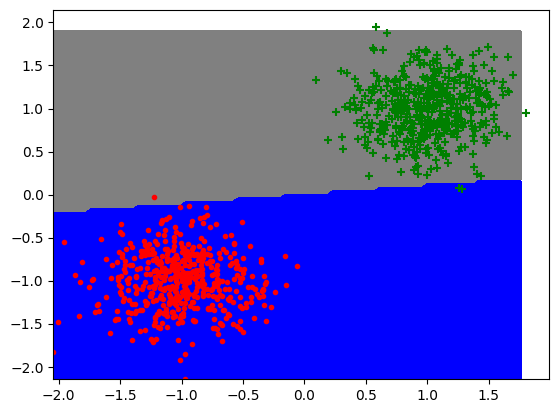

In [48]:
# Génération de données artificielles selon 2 gaussiennes
datax, datay = gen_arti(data_type=0)

# Frontière de décision avec un w aléatoire (avant apprentissage)
w_random = np.random.randn(datax.shape[1], 1)
plot_frontiere(datax, lambda x: np.sign(x @ w_random), step=100)
plot_data(datax, datay)

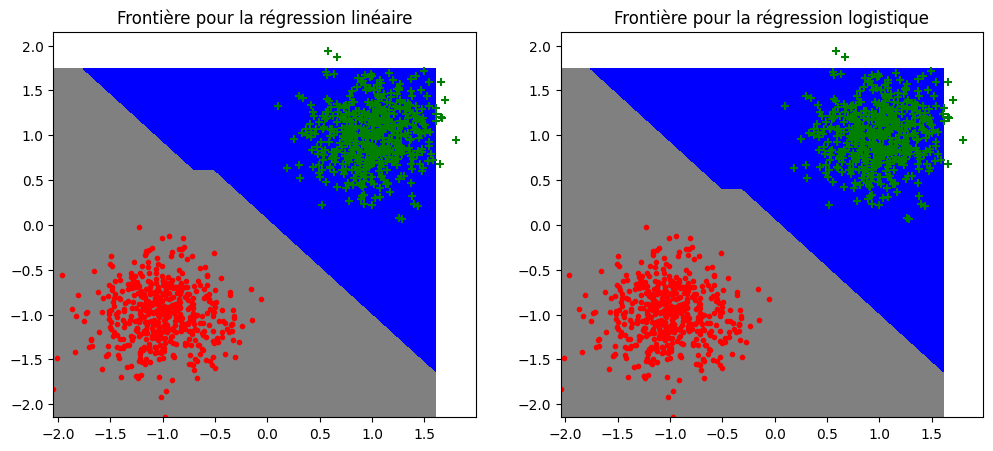

In [49]:
# Descente de gradient pour la régression linéaire
w_lin, list_w_lin, losses_lin = descente_gradient(datax, datay, mse, mse_grad, eps=0.01, iter=100)

# Descente de gradient pour la régression logistique
w_log, list_w_log, losses_log = descente_gradient(datax, datay, reglog, reglog_grad, eps=0.1, iter=100)

# Fonction de prédiction
def f_lin(x): return np.sign(x @ w_lin)
def f_log(x): return np.sign(x @ w_log)

# Visualisation des frontières
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_frontiere(datax, f_lin)
plot_data(datax, datay)
plt.title("Frontière pour la régression linéaire")

plt.subplot(1, 2, 2)
plot_frontiere(datax, f_log)
plot_data(datax, datay)
plt.title("Frontière pour la régression logistique")

plt.show()

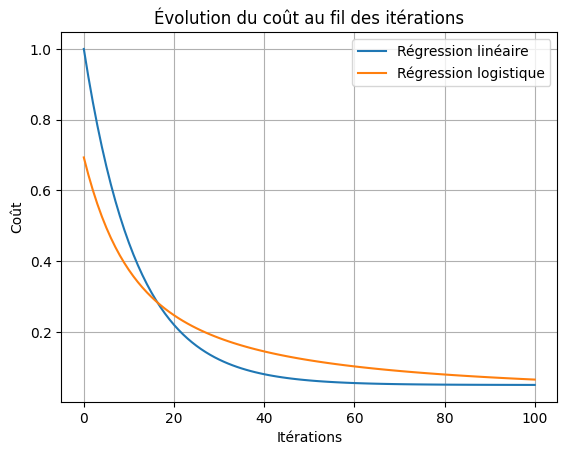

In [50]:
# Evolution du coût au fil des itérations
plt.figure()
plt.plot(losses_lin, label="Régression linéaire")
plt.plot(losses_log, label="Régression logistique")
plt.xlabel("Itérations")
plt.ylabel("Coût")
plt.title("Évolution du coût au fil des itérations")
plt.legend()
plt.grid(True)
plt.show()

La convergence de l'algorithme dépend fortement du pas de gradient. Un pas trop grand peut provoquer des oscillations ou une divergence (sauts au-dessus de l'optimum), surtout dans les problèmes non séparables. En revanche, un pas trop petit assure une convergence plus stable, mais plus lente. De plus, dans les problèmes non séparables avec du bruit, un petit pas évite les oscillations mais peut bloquer l'algorithme dans un minimum local. 

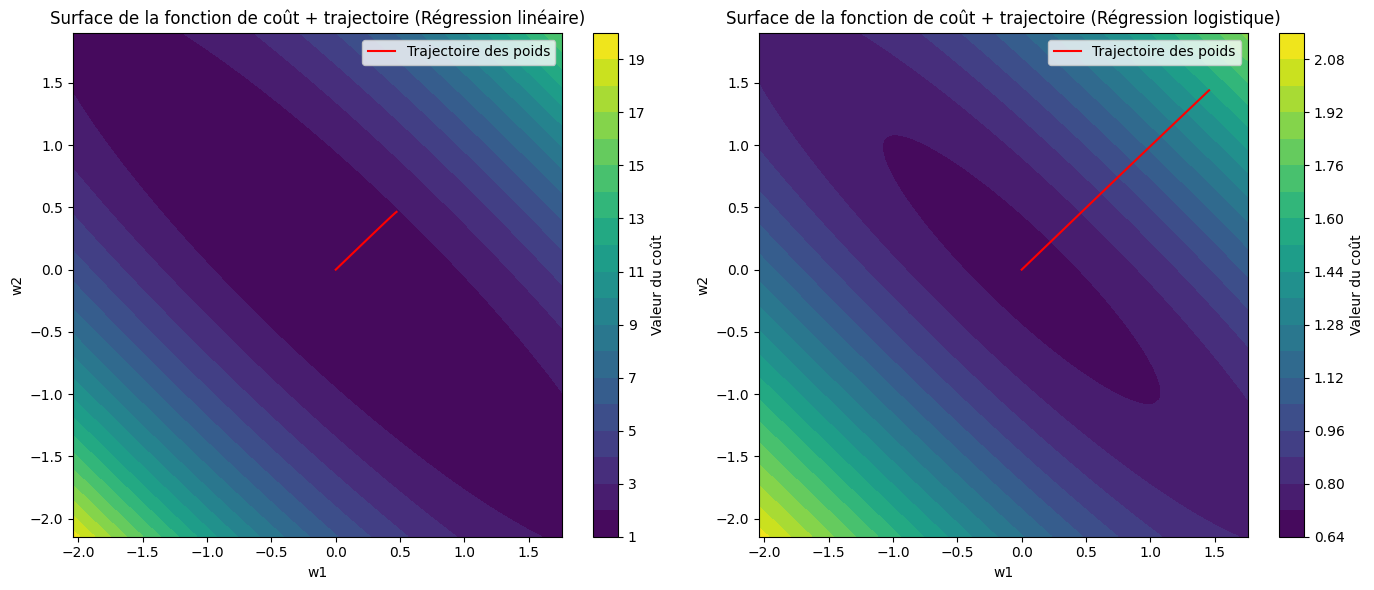

In [52]:
# Visualisation de la fonction de coût en 2D pour la régression linéaire et logistique
grid, x_grid, y_grid = make_grid(datax, step=100)

plt.figure(figsize=(14, 6))

# Régression linéaire
plt.subplot(1, 2, 1)
plt.contourf(x_grid, y_grid, np.array([mse(w, datax, datay).mean() for w in grid]).reshape(x_grid.shape), levels=20)
plt.colorbar(label="Valeur du coût")
w_lin_array = np.array(list_w_lin).squeeze()
plt.plot(w_lin_array[:, 0], w_lin_array[:, 1], color='red', markersize=2, label="Trajectoire des poids")
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Surface de la fonction de coût + trajectoire (Régression linéaire)")
plt.legend()

# Régression logistique
plt.subplot(1, 2, 2)
plt.contourf(x_grid, y_grid, np.array([reglog(w, datax, datay).mean() for w in grid]).reshape(x_grid.shape), levels=20)
plt.colorbar(label="Valeur du coût")
w_log_array = np.array(list_w_log).squeeze()
plt.plot(w_log_array[:, 0], w_log_array[:, 1], color='red', markersize=2, label="Trajectoire des poids")
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Surface de la fonction de coût + trajectoire (Régression logistique)")
plt.legend()

plt.tight_layout() 
plt.show()


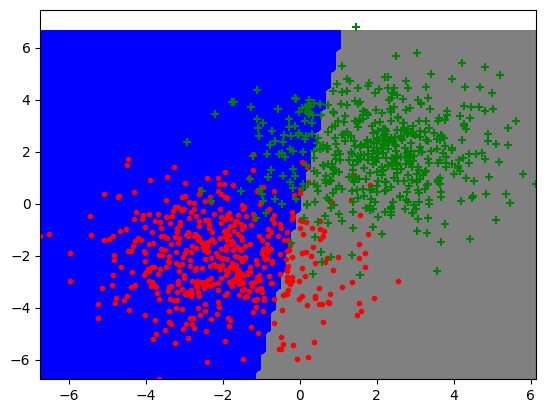

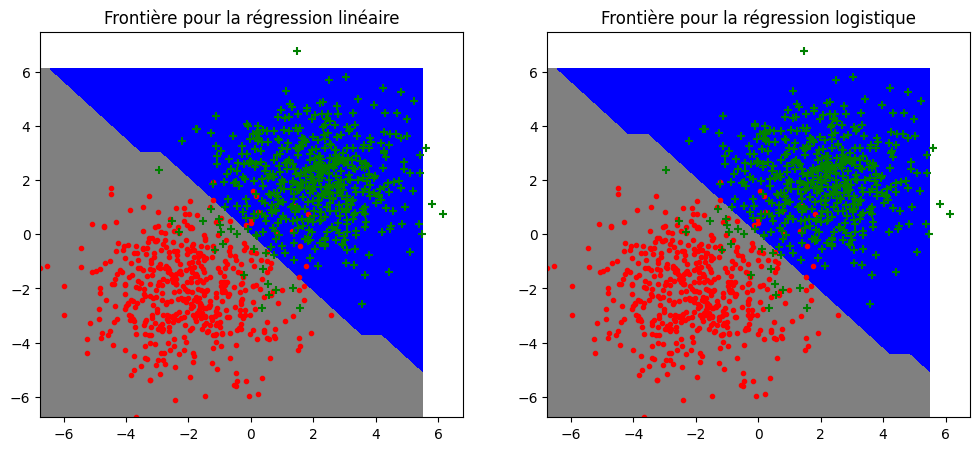

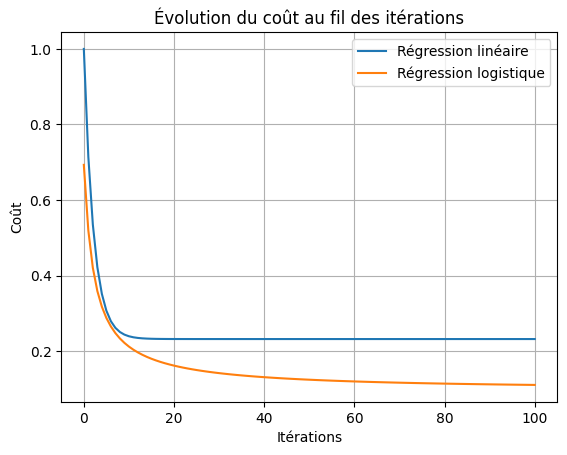

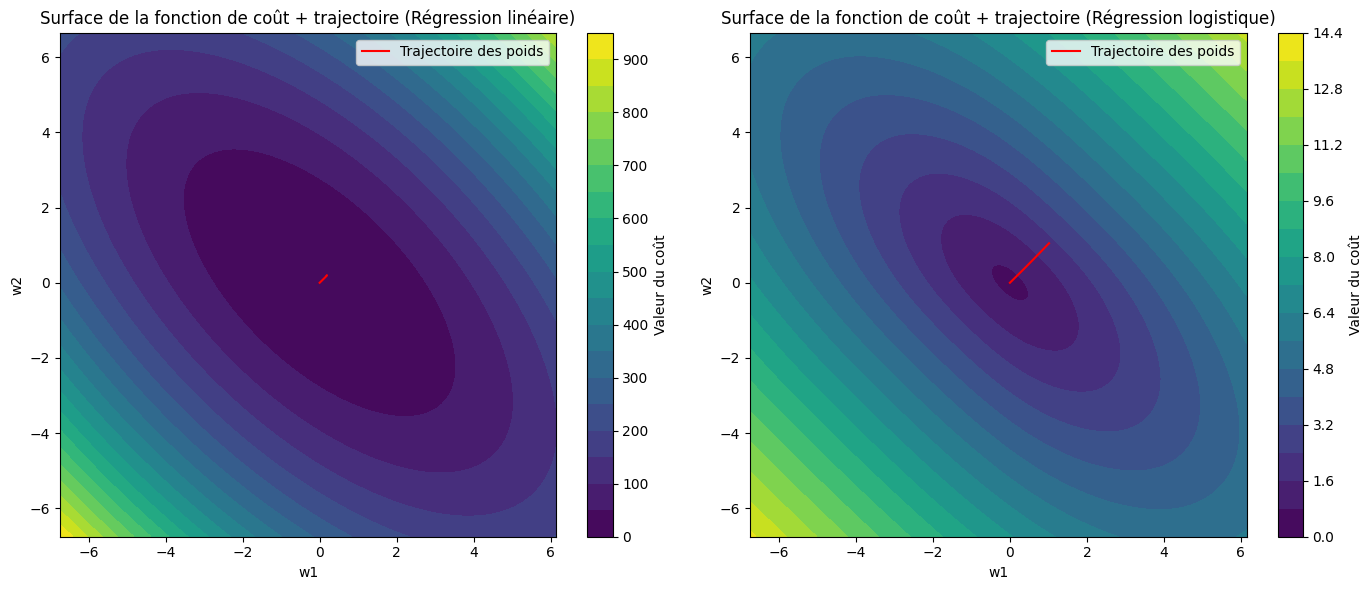

In [57]:
# Génération de données artificielles selon 4 gaussiennes
datax, datay = gen_arti(centerx=2, centery=2, sigma=0.2, nbex=1000, data_type=0, epsilon=1.5)

# Frontière de décision avec un w aléatoire (avant apprentissage)
w_random = np.random.randn(datax.shape[1], 1)
plot_frontiere(datax, lambda x: np.sign(x @ w_random), step=100)
plot_data(datax, datay)

# Descente de gradient pour la régression linéaire
w_lin, list_w_lin, losses_lin = descente_gradient(datax, datay, mse, mse_grad, eps=0.01, iter=100)

# Descente de gradient pour la régression logistique
w_log, list_w_log, losses_log = descente_gradient(datax, datay, reglog, reglog_grad, eps=0.1, iter=100)

# Fonction de prédiction
def f_lin(x): return np.sign(x @ w_lin)
def f_log(x): return np.sign(x @ w_log)

# Visualisation des frontières
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_frontiere(datax, f_lin)
plot_data(datax, datay)
plt.title("Frontière pour la régression linéaire")

plt.subplot(1, 2, 2)
plot_frontiere(datax, f_log)
plot_data(datax, datay)
plt.title("Frontière pour la régression logistique")

plt.show()

# Evolution du coût au fil des itérations
plt.figure()
plt.plot(losses_lin, label="Régression linéaire")
plt.plot(losses_log, label="Régression logistique")
plt.xlabel("Itérations")
plt.ylabel("Coût")
plt.title("Évolution du coût au fil des itérations")
plt.legend()
plt.grid(True)
plt.show()

# Visualisation de la fonction de coût en 2D pour la régression linéaire et logistique
grid, x_grid, y_grid = make_grid(datax, step=100)

plt.figure(figsize=(14, 6))

# Régression linéaire
plt.subplot(1, 2, 1)
plt.contourf(x_grid, y_grid, np.array([mse(w, datax, datay).mean() for w in grid]).reshape(x_grid.shape), levels=20)
plt.colorbar(label="Valeur du coût")
w_lin_array = np.array(list_w_lin).squeeze()
plt.plot(w_lin_array[:, 0], w_lin_array[:, 1], color='red', markersize=2, label="Trajectoire des poids")
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Surface de la fonction de coût + trajectoire (Régression linéaire)")
plt.legend()

# Régression logistique
plt.subplot(1, 2, 2)
plt.contourf(x_grid, y_grid, np.array([reglog(w, datax, datay).mean() for w in grid]).reshape(x_grid.shape), levels=20)
plt.colorbar(label="Valeur du coût")
w_log_array = np.array(list_w_log).squeeze()
plt.plot(w_log_array[:, 0], w_log_array[:, 1], color='red', markersize=2, label="Trajectoire des poids")
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Surface de la fonction de coût + trajectoire (Régression logistique)")
plt.legend()

plt.tight_layout() 
plt.show()